In [61]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

## Here we are going to combine linear regression and LSTM models

In [62]:
df=  pd.read_csv("/content/apple_stock_data.csv")
df.head()

,Date,Adj Close,Close,High,Low,Open,Volume
0,2023-11-02 00:00:00+00:00,176.665985,177.570007,177.779999,175.460007,175.520004,77334800
1,2023-11-03 00:00:00+00:00,175.750671,176.649994,176.820007,173.350006,174.240005,79763700
2,2023-11-06 00:00:00+00:00,178.317520,179.229996,179.429993,176.210007,176.380005,63841300
3,2023-11-07 00:00:00+00:00,180.894333,181.820007,182.440002,178.970001,179.179993,70530000
4,2023-11-08 00:00:00+00:00,181.958893,182.889999,183.449997,181.589996,182.350006,49340300


In [63]:
from datetime import datetime

In [64]:
## convert to date time
df["Date"]=pd.to_datetime(df["Date"])

## set the index to Date

df.set_index('Date',inplace=True)

## Focus on the close price

df= df[["Close"]]

In [65]:
df[["Close"]]

,Close
Date,
2023-11-02 00:00:00+00:00,177.570007
2023-11-03 00:00:00+00:00,176.649994
2023-11-06 00:00:00+00:00,179.229996
2023-11-07 00:00:00+00:00,181.820007
2023-11-08 00:00:00+00:00,182.889999
...,...
2024-10-28 00:00:00+00:00,233.399994
2024-10-29 00:00:00+00:00,233.669998
2024-10-30 00:00:00+00:00,230.100006


In [66]:
df.head()

,Close
Date,
2023-11-02 00:00:00+00:00,177.570007
2023-11-03 00:00:00+00:00,176.649994
2023-11-06 00:00:00+00:00,179.229996
2023-11-07 00:00:00+00:00,181.820007
2023-11-08 00:00:00+00:00,182.889999


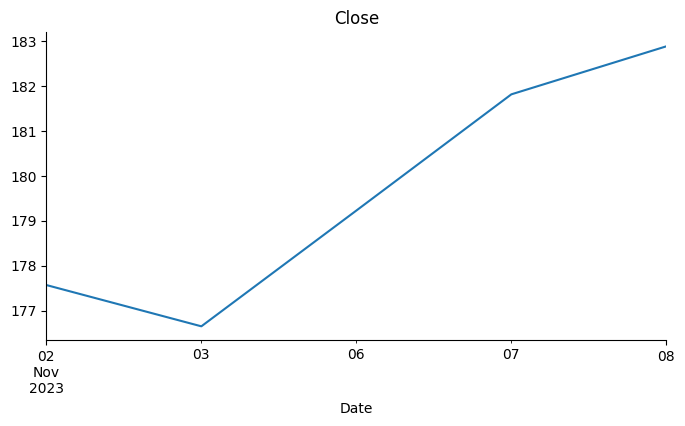

In [67]:
from matplotlib import pyplot as plt
_df_1['Close'].plot(kind='line', figsize=(8, 4), title='Close')
plt.gca().spines[['top', 'right']].set_visible(False)

### LSTM + Linear regression


In [68]:
## Scaling the close price of the data to between 0's and 1's using MinMax Scaler

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))
df[["Close"]]= scaler.fit_transform(df[['Close']])

In [69]:
df[["Close"]].head()

,Close
Date,
2023-11-02 00:00:00+00:00,0.175853
2023-11-03 00:00:00+00:00,0.162983
2023-11-06 00:00:00+00:00,0.199077
2023-11-07 00:00:00+00:00,0.235311
2023-11-08 00:00:00+00:00,0.250280


In [70]:
df[["Close"]].std()[0] ## standard Deviation value

<ipython-input-70-1b37e22f6bb7>:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df[["Close"]].std()[0] ## standard Deviation value


0.2982871868625514

In [71]:
print(f"length: {len(df)}")
print(f"shape of data: {df.shape}")

length: 252
shape of data: (252, 1)


In [72]:
## Create a data for LSTM by creating a sequences of defined length of 60 to predict the next days stock  price
import numpy as np
def create_sequence(data,seq_length=60):
  X,y= [],[]
  for i in range(len(data)- seq_length):
    X.append(data[i:i+seq_length])
    y.append(data[i+seq_length])
  return np.array(X), np.array(y)

seq_length=60
X,y= create_sequence(df[["Close"]].values,seq_length)


In [73]:
## Split train and test data
train_data= int(len(X)* 0.80)
print(train_data)
X_train,X_test= X[:train_data], X[train_data:]
y_train,y_test= y[:train_data],y[train_data:]

153


In [74]:
# ## Split the train and test data
# from sklearn.model_selection import train_test_split
# X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.25,random_state=7)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(153, 60, 1) (153, 1)
(39, 60, 1) (39, 1)


In [75]:
## Now we will build the Sequential LSTM model with layers to capture the temporal dependencies in the data
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

lstm_model=Sequential()
lstm_model.add(LSTM(units=50,activation='tanh',return_sequences=True,input_shape=(X_train.shape[1],1)))
lstm_model.add(LSTM(units=50))
lstm_model.add(Dense(1))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [76]:
## now compile the data
lstm_model.compile(optimizer="adam",loss="mean_squared_error")
lstm_model.fit(X_train,y_train,epochs=20,batch_size=32)

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - loss: 0.2541
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - loss: 0.0378
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0449
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0162
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0186
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0148
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0115
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.0113
Epoch 9/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0102
Epoch 10/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0100
Epoch 11/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0098
Epoch 12/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0091
Epoch 13/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0092
Epoch 14/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0081
Epoch 15/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0087
Epoch 16/20
5/5 ━━━━━━━━━━━━━━━━━━

In [77]:
## now lets train the second model using linear regression for the lagged features (eg using past 3 days as predictors)

df['Lag_1']= df[["Close"]].shift(1)
df['Lag_2']=df[["Close"]].shift(2)
df['Lag_3']=df[["Close"]].shift(3)
df=df.dropna()

In [83]:
## Now we will split the data

X_lin=df[['Lag_1','Lag_2','Lag_3']]
y_lin=df[['Close']]
X_train_lin,X_test_lin= X_lin[:train_data],X_lin[train_data:]
y_train_lin,y_test_lin=y_lin[:train_data],y_lin[train_data:]

In [84]:
## Now lets train the Linear regression model
from sklearn.linear_model import LinearRegression
lin_model= LinearRegression()
lin_model.fit(X_train_lin,y_train_lin)

LinearRegression()

In [89]:
## now make preditions using LSTM on test set and inverse transform the scaled predictions
X_test_lstm= X_test.reshape((X_test.shape[0],X_test.shape[1],1))
lstm_predictions= lstm_model.predict(X_test_lstm)
lstm_predictions= scaler.inverse_transform(lstm_predictions)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


In [90]:
## heres how to predict using linear Regression and inverse transform then
lin_predictions= lin_model.predict(X_test_lin)
lin_predictions= scaler.inverse_transform(lin_predictions.reshape(-1,1))

In [93]:
# ## use weighted average to create a hybrid predictions
# hybrid_predictions= np.broadcast((0.7 * lstm_predictions), (0.3 * lin_predictions))

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (39, 1) and arg 1 with shape (96, 1).

In [98]:
## predict using hybrid model
## for next 10 days stock price using LSTM
lstm_future_predictions=[]
last_sequence= X[-1].reshape(1,seq_length,1)
for _ in range(10):
  lstm_pred= lstm_model.predict(last_sequence)[0,0]
  lstm_future_predictions.append(lstm_pred)
  lstm_pred_reshape= np.array([[lstm_pred]]).reshape(1,1,1)
  last_sequence= np.append(last_sequence[:,1:,:], lstm_pred_reshape, axis=1)

lstm_future_predictions= scaler.inverse_transform(np.array(lstm_future_predictions).reshape(-1,1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


In [100]:
## Predict using Linear Regression
recent_data= df[['Close']].values[-3:]
lin_future_predictions=[]
for _ in range(10):
  lin_pred= lin_model.predict(recent_data.reshape(1,-1))[0]
  lin_future_predictions.append(lin_pred)
  recent_data=np.append(recent_data[1:],lin_pred)

lin_future_predictions= scaler.inverse_transform(np.array(lin_future_predictions).reshape(-1,1))

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature n

In [103]:
## use weighted average to create a hybrid predictions
hybrid_predictions= (0.7 * lstm_future_predictions)+ (0.3 * lin_future_predictions)

In [104]:
future_dates= pd.date_range(start=df.index[-1] + pd.Timedelta(days=1), periods=10)
predictions_df= pd.DataFrame({
    "Date": future_dates,
    "LSTM Predictions" : lstm_future_predictions.flatten(),
    "Linear Predictions": lin_future_predictions.flatten(),
    "Hybrid Model Predictions": hybrid_predictions.flatten()
})

print(predictions_df)

                       Date  LSTM Predictions  Linear Predictions  \
0 2024-11-02 00:00:00+00:00        231.559601          230.355192   
1 2024-11-03 00:00:00+00:00        231.230865          225.707291   
2 2024-11-04 00:00:00+00:00        230.931931          222.703426   
3 2024-11-05 00:00:00+00:00        230.657578          230.631535   
4 2024-11-06 00:00:00+00:00        230.400620          225.486380   
5 2024-11-07 00:00:00+00:00        230.155121          222.494588   
6 2024-11-08 00:00:00+00:00        229.916183          230.930195   
7 2024-11-09 00:00:00+00:00        229.680496          225.245599   
8 2024-11-10 00:00:00+00:00        229.445938          222.284007   
9 2024-11-11 00:00:00+00:00        229.211060          231.252375   

   Hybrid Model Predictions  
0                231.198278  
1                229.573790  
2                228.463372  
3                230.649757  
4                228.926340  
5                227.856958  
6                230.220389  
